In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data (same as before)
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

X = df.drop('target', axis=1)
y = df['target']

# Split first, BEFORE resizing numbers - keeps the test set truly hidden/fair
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Resize all number columns so they're on a comparable scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up all 4 guessing methods in one place
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Train each one, test each one, save its scores
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

# Turn the results into a clean table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression  0.852459   0.870968  0.84375  0.857143
1        Random Forest  0.836066   0.843750  0.84375  0.843750
2                  SVM  0.868852   0.900000  0.84375  0.870968
3                  KNN  0.901639   0.933333  0.87500  0.903226


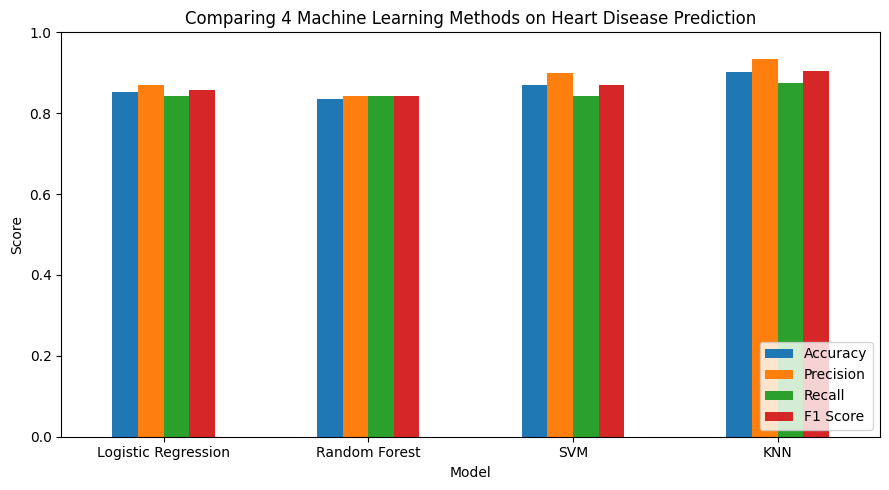

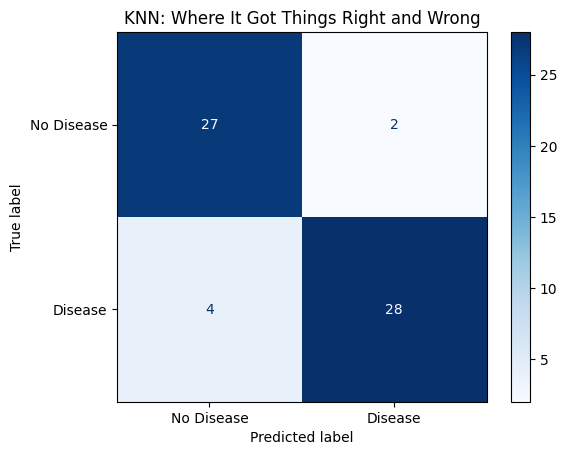

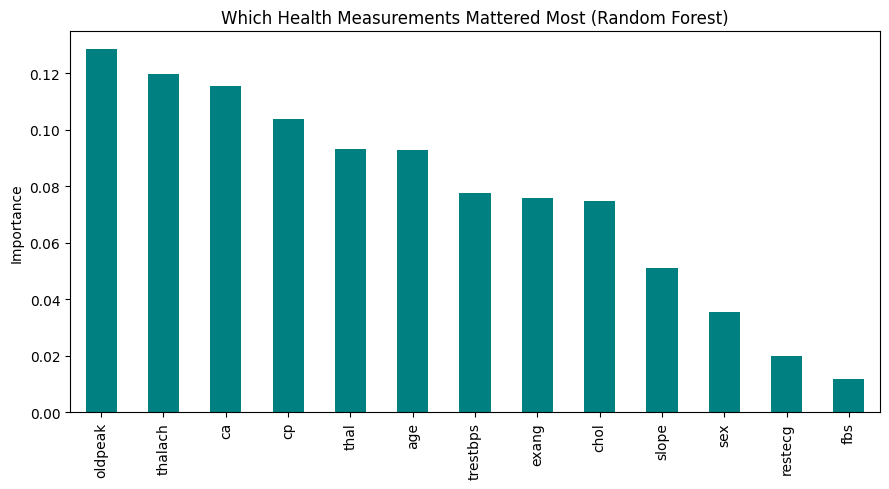

oldpeak     0.128485
thalach     0.119725
ca          0.115533
cp          0.103792
thal        0.093300
age         0.092811
trestbps    0.077537
exang       0.075809
chol        0.074812
slope       0.051058
sex         0.035658
restecg     0.019782
fbs         0.011698
dtype: float64


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Chart 1: Compare all 4 models side by side ---
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(9,5))
plt.title("Comparing 4 Machine Learning Methods on Heart Disease Prediction")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison_chart.png")   # saves the image so you can drop it into the paper
plt.show()

# --- Chart 2: A closer look at KNN, the best performing model ---
best_model = models["KNN"]
preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("KNN: Where It Got Things Right and Wrong")
plt.savefig("knn_confusion_matrix.png")
plt.show()

# --- Bonus: which health measurements mattered most (from Random Forest) ---
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.plot(kind="bar", figsize=(9,5), color="teal")
plt.title("Which Health Measurements Mattered Most (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_chart.png")
plt.show()

print(importances)